In [150]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter_2 import kalman_filter as kf
from scipy import signal
from scipy.stats import pearsonr

# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data

Choose the time interval for which the model is to be run.

In [151]:
#choose time period of runs
slice_str = "2024-07-01 00:00:00, 2024-07-31 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.

- **Surface variables** include:
  - Surface air temperature
  - Surface pressure
  - Surface dew point temperature

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [152]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

Storing the time values and the timestep.

In [153]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

Choose how often then Kalman filter is implemented

In [154]:
kalman_hours_1 = 1
kalman_indices_1 = np.mean(np.round(kalman_hours_1*3600/dt_seconds)).astype(int)
kalman_hours_2 = 2
kalman_indices_2 = np.mean(np.round(kalman_hours_2*3600/dt_seconds)).astype(int)
kalman_hours_3 = 3
kalman_indices_3 = np.mean(np.round(kalman_hours_3*3600/dt_seconds)).astype(int)

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [155]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


#### Radiometer LWC 

In [185]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')


#### Environmental profiles and inputs

The model inputs

In [ ]:
#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

## Running the model

In [ ]:
#state for the model without KF and with 3 different KFs- cloud liquid water
X = np.zeros(len(T_surf))
X_1 = np.zeros(len(T_surf))
X_2 = np.zeros(len(T_surf))
X_3 = np.zeros(len(T_surf))

#precipitation on the ground without KF and with 3 different KFs
P = np.zeros(len(T_surf))
P_1 = np.zeros(len(T_surf))
P_2 = np.zeros(len(T_surf))
P_3 = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))

#updraft velocity
v_updr_arr = np.zeros(len(T_surf))

#liquid water inputs and ``
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_t_arr = np.zeros(len(T_surf))
Q = 0.32

#cloud top pressure and cloud depth
p_t_arr = np.zeros(len(T_surf))
Z_c_arr = np.zeros(len(T_surf))

In [ ]:
X[0] = radiometer_lwp[0]   #initial state in kg/m2
X_1[0] = radiometer_lwp[0]   #initial state in kg/m2
X_2[0] = radiometer_lwp[0]  #initial state in kg/m2
X_3[0] = radiometer_lwp[0]   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

Sigma_1 = np.zeros(len(T_surf))
Sigma_1[0] = 1 #initial state covariance in kg/m2
Sigma_2 = np.zeros(len(T_surf))
Sigma_2[0] = 1 #initial state covariance in kg/m2
Sigma_3 = np.zeros(len(T_surf))
Sigma_3[0] = 1 #initial state covariance in kg/m2

In [ ]:
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    p_t_arr[i] = p_t
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    v_updr_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    O_b_arr[i] = O_b*non_dim_numbers(v_updr)[0]/(Z_c)
    O_t_arr[i] = O_t*non_dim_numbers(v_updr)[0]/(Z_c)   
    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
    Z_c_arr[i] = Z_c
    #precipitation in kg/m2/s
    #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3600)
    #state without Kalman filter
    P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]
    P_1[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_1[i]
    P_2[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_2[i]
    P_3[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X_3[i]
    
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>0:

        if i<(len(T_surf)-1):
            X[i+1] = X[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])
            Sigma[i+1] = Sigma[i] + 2*(h_v*Sigma[i])*dt_seconds[i] + Q*dt_seconds[i]

            X_1[i+1] = X_1[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_1[i])
            Sigma_1[i+1] = Sigma_1[i] + 2*(h_v*Sigma_1[i])*dt_seconds[i] + Q*dt_seconds[i]  

            X_2[i+1] = X_2[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_2[i])
            Sigma_2[i+1] = Sigma_2[i] + 2*(h_v*Sigma_2[i])*dt_seconds[i] + Q*dt_seconds[i]

            X_3[i+1] = X_3[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X_3[i])
            Sigma_3[i+1] = Sigma_3[i] + 2*(h_v*Sigma_3[i])*dt_seconds[i] + Q*dt_seconds[i]

        if (((i%kalman_indices_1)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X_1[i], Sigma_1[i], dt_seconds[i],h_kf,phi_kf,f_kf,rain_rate[i].values) 
            X_1[i+1],Sigma_1[i+1],X_apr = kalman_f.update()    

        if (((i%kalman_hours_2)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X_2[i], Sigma_2[i], dt_seconds[i],h_kf,phi_kf,f_kf,rain_rate[i].values) 
            X_2[i+1],Sigma_2[i+1],X_apr = kalman_f.update()

        if (((i%kalman_indices_3)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X_3[i], Sigma_3[i], dt_seconds[i],h_kf,phi_kf,f_kf,rain_rate[i].values) 
            X_3[i+1],Sigma_3[i+1],X_apr = kalman_f.update()

2
4
6
6
8
10
12
12
14
16
18
18
18
20
22
24
24
26
28
30
30
32
34
36
36
36
38
40
42
42
44
46
48
48
50
52
54
54
54
56
58
60
60
62
64
66
66
68
70
72
72
72
74
76
78
78
80
82
84
84
86
88
90
90
90
92
94
96
96
98
100
102
102
104
106
108
108
108
110
112
114
114
116
118
120
120
122
124
126
126
126
128
130
132
132
134
136
138
138
140
142
144
144
144
146
148
150
150
152
154
156
156
158
160
162
162
162
164
166
168
168
170
172
174
174
176
178
180
180
180
182
184
186
186
188
190
192
192
194
196
198
198
198
200
202
204
204
206
208
210
210
212
214
216
216
216
218
220
222
222
224
226
228
228
230
232
234
234
234
236
238
240
240
242
244
246
246
248
250
252
252
252
254
256
258
258
260
262
264
264
266
268
270
270
270
272
274
276
276
278
280
282
282
284
286
288
288
288
290
292
294
294
296
298
300
300
302
304
306
306
306
308
310
312
312
314
316
318
318
320
322
324
324
324
326
328
330
330
332
334
336
336
338
340
342
342
342
344
346
348
348
350
352
354
354
356
358
360
360
360
362
364
366
366
368
370
372
372
374

C:\Users\chari\AppData\Local\Temp\ipykernel_14312\1232121435.py:52: RuntimeWarning: overflow encountered in add
  Sigma[i+1] = Sigma[i] + 2*(h_v*Sigma[i])*dt + Q*dt


1810
1812
1812
1814
1816
1818
1818
1818
1820
1822
1824
1824
1826
1828
1830
1830
1832
1834
1836
1836
1836
1838
1840
1842
1842
1844
1846
1848
1848
1850
1852
1854
1854
1854
1856
1858
1860
1860
1862
1864
1866
1866
1868
1870
1872
1872
1872
1874
1876
1878
1878
1880
1882
1884
1884
1886
1888
1890
1890
1890
1892
1894
1896
1896
1898
1900
1902
1902
1904
1906
1908
1908
1908
1910
1912
1914
1914
1916
1918
1920
1920
1922
1924
1926
1926
1926
1928
1930
1932
1932
1934
1936
1938
1938
1940
1942
1944
1944
1944
1946
1948
1950
1950
1952
1954
1956
1956
1958
1960
1962
1962
1962
1964
1966
1968
1968
1970
1972
1974
1974
1976
1978
1980
1980
1980
1982
1984
1986
1986
1988
1990
1992
1992
1994
1996
1998
1998
1998
2000
2002
2004
2004
2006
2008
2010
2010
2012
2014
2016
2016
2016
2018
2020
2022
2022
2024
2026
2028
2028
2030
2032
2034
2034
2034
2036
2038
2040
2040
2042
2044
2046
2046
2048
2050
2052
2052
2052
2054
2056
2058
2058
2060
2062
2064
2064
2066
2068
2070
2070
2070
2072
2074
2076
2076
2078
2080
2082
2082
2084
2086


## Visualizing the outputs

Text(0, 0.5, 'In cloud Liquid Water Content [g/m3]')

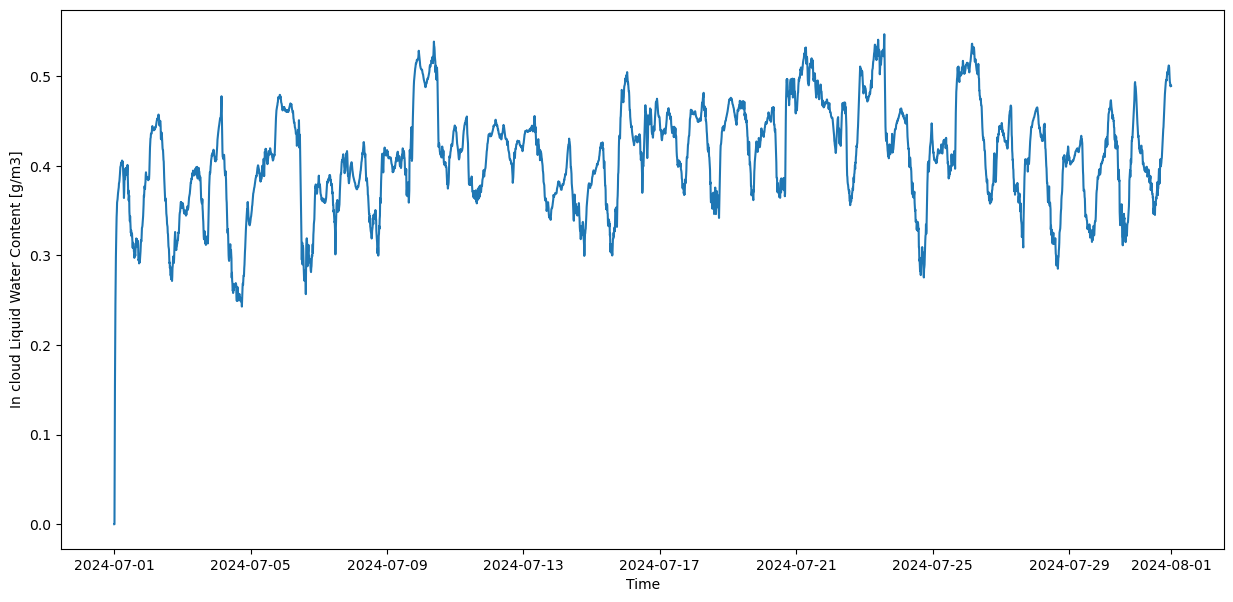

In [159]:
index_rain = np.where((P*3600 > 0.25))[0]
index_no_rain = np.where((rain_rate==0) & (P*3600 < 0.25))[0]
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(measurements_used.time, X/Z_c_arr*1000)  # Adjust based on your data structure
ax.set_xlabel('Time')
ax.set_ylabel('In cloud Liquid Water Content [g/m3]')
# Add vertical lines at the corresponding times
#for idx in index_rain:
    #ax.axvline(measurements_used.time[idx].values, color='blue', linestyle='--', alpha=0.3)
#for idx in index_no_rain:
    #ax.axvline(measurements_used.time[idx].values, color='red', linestyle='--', alpha=0.3)



Text(0, 0.5, 'Cloud Top Pressure')

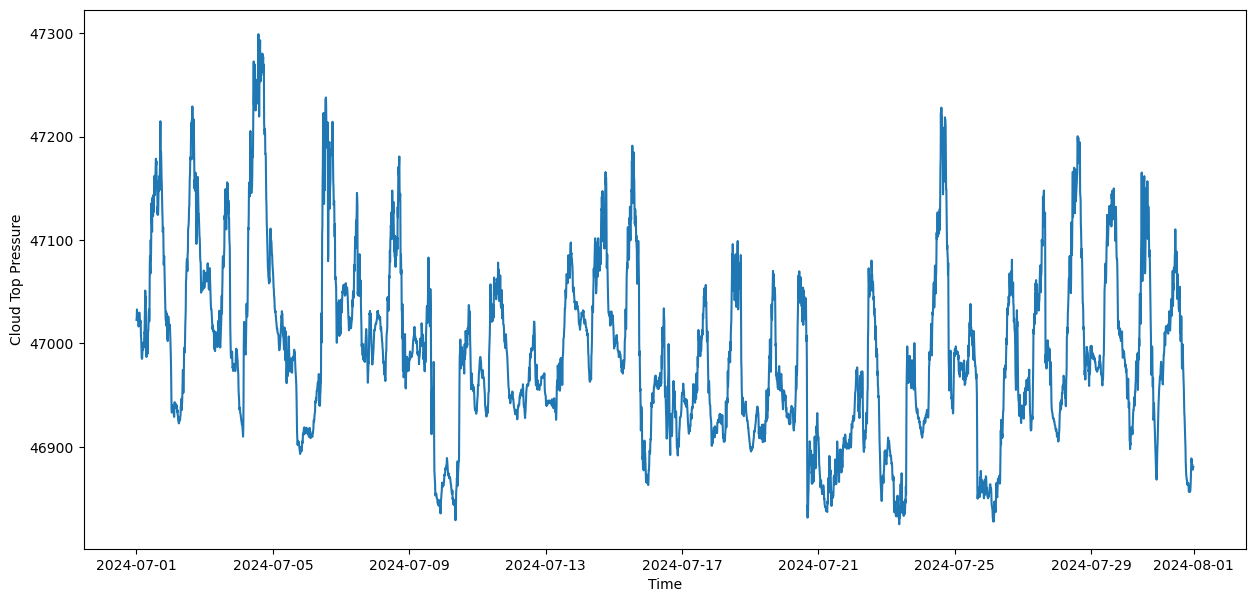

In [160]:
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(measurements_used.time, p_t_arr)  # Adjust based on your data structure
ax.set_xlabel('Time')
ax.set_ylabel('Cloud Top Pressure')

Text(0, 0.5, 'Vertically Averaged Updraft Velocity [m/s]')

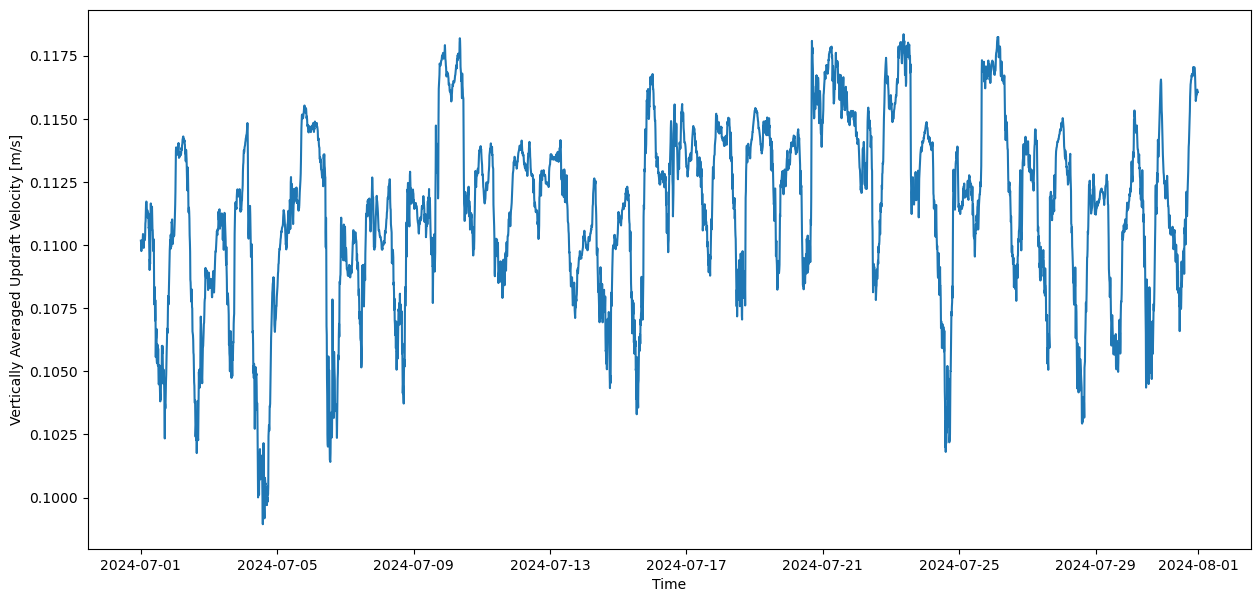

In [161]:
fig, ax = plt.subplots(figsize=(15,7))
ax.plot(measurements_used.time, v_updr_arr)  # Adjust based on your data structure
ax.set_xlabel('Time')
ax.set_ylabel('Vertically Averaged Updraft Velocity [m/s]')

Text(0.5, 0, 'time')

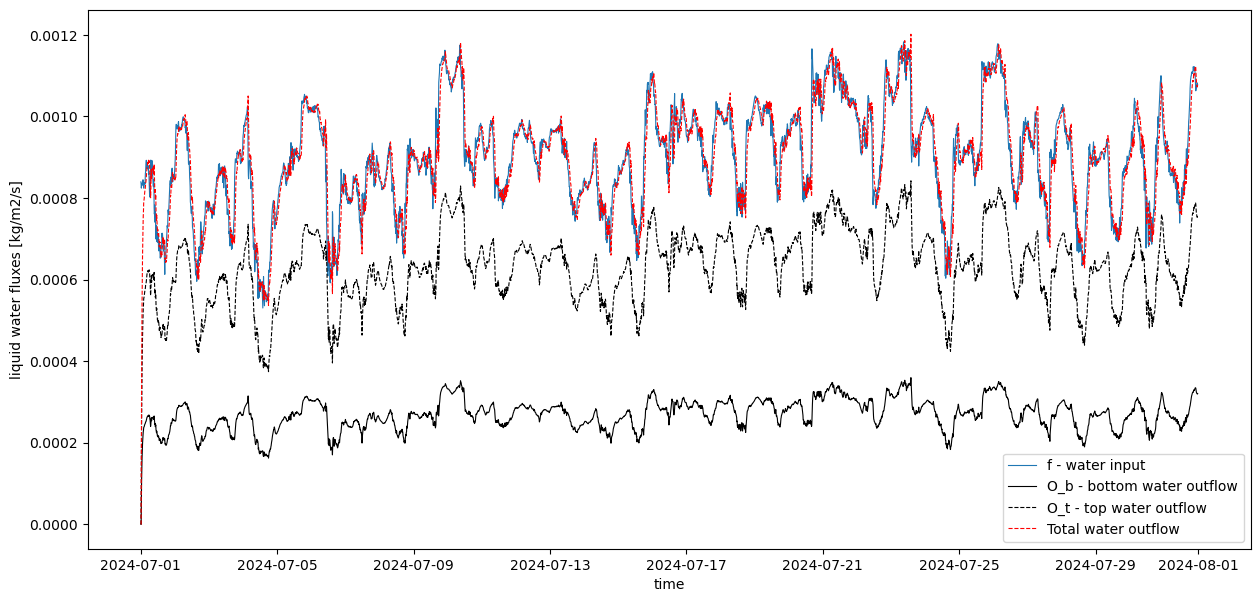

In [162]:
fig, ax = plt.subplots(figsize=(15,7))
plt.plot(measurements_used.time, f_arr,linewidth=0.8,label='f - water input')
plt.plot(measurements_used.time, O_b_arr*X,linewidth=0.8,label='O_b - bottom water outflow',color='black')
plt.plot(measurements_used.time, O_t_arr*X,linewidth=0.8,label='O_t - top water outflow',color='black',linestyle='--')
plt.plot(measurements_used.time, (O_t_arr+O_b_arr)*X,linewidth=0.8,label='Total water outflow',linestyle='--',color='red')
plt.legend()
plt.ylabel('liquid water fluxes [kg/m2/s]')
plt.xlabel('time')

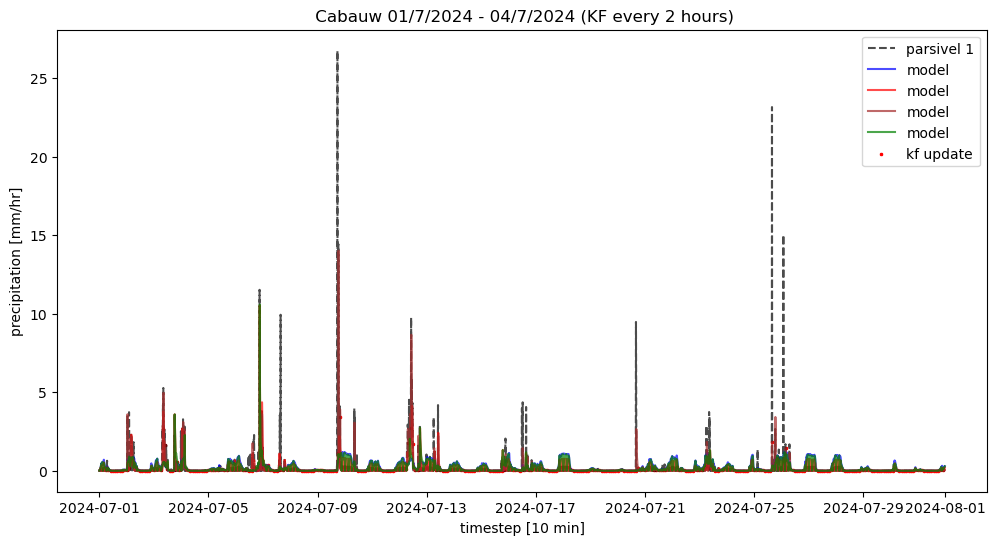

In [192]:
plt.figure(figsize=(12,6))

#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(time,rain_rate,label='parsivel 1',color='black',alpha=0.7,linestyle='--') 
plt.plot(time,P*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(time,P_1*3600,label='model',color='red',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(time,P_2*3600,label='model',color='brown',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(time,P_3*3600,label='model',color='green',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.scatter(time[kalman_indices_2::kalman_indices_2],P_2[kalman_indices_2::kalman_indices_2]*3600,label='kf update',marker='x',s=3,color='red')
plt.xlabel('timestep [10 min]')
plt.title(' Cabauw 01/7/2024 - 04/7/2024 (KF every 2 hours)')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.grid()
plt.show()


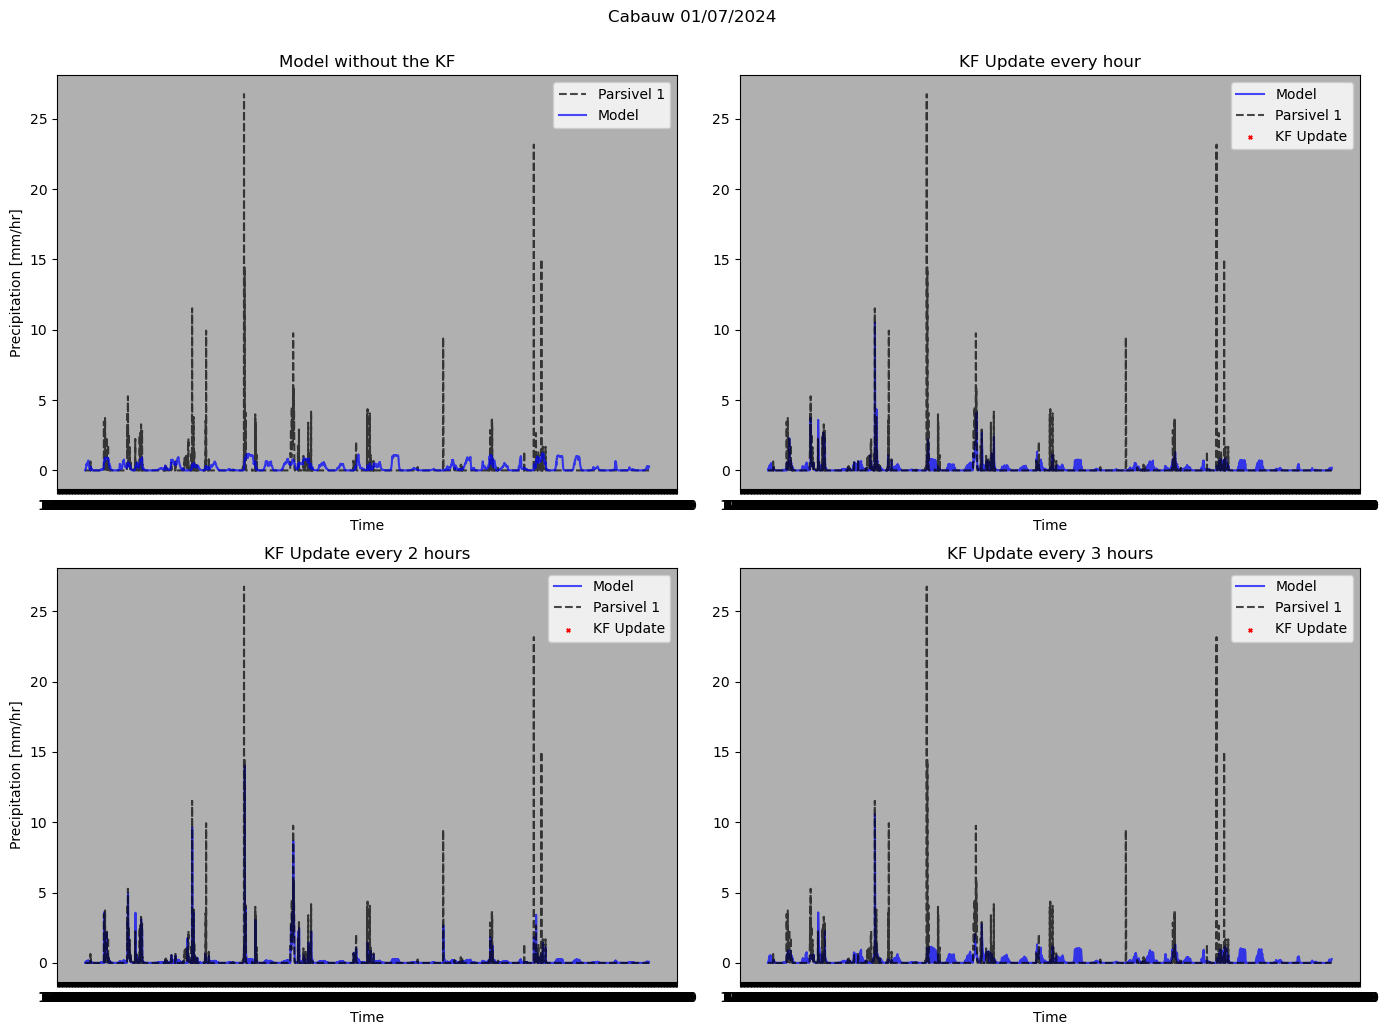

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
# Create a 2x2 grid for subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10)) 

# Example time series data (assuming these are already defined)
# measurements_used, rain_rate, P, P_1, P_2, P_3 need to be defined earlier in your code
#t_step = np.linspace(0, len(P), len(P))

#slice_tuple_2 = ('2024-07-01 00:00:00', '2024-07-01 10:59:00')

#indexes = measurements_used.sel(time=slice(*slice_tuple_2)).time
#index_positions = [measurements_used.get_index("time").get_loc(t) for t in indexes.values]

# Define the time slice for the plot
#time_slice = measurements_used.time.sel(time=slice(*slice_tuple_2))

# Panel 1 - Plot model vs observed (rain rate)
axs[0, 0].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[0, 0].plot(time, P* 3600, label='Model', color='blue', alpha=0.7)

axs[0, 0].set_title('Model without the KF')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Precipitation [mm/hr]')
axs[0, 0].legend()
axs[0, 0].grid()

# Panel 4 - Scatter plot (KF Update)
axs[0, 1].plot(time, P_1 * 3600, label='Model', color='blue', alpha=0.7)
axs[0, 1].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[0, 1].scatter(time[kalman_indices_1::kalman_indices_1], P_1[kalman_indices_1::kalman_indices_1]* 3600, label='KF Update', marker='x', s=6, color='red')
axs[0, 1].set_title('KF Update every hour')
axs[0, 1].set_xlabel('Time')
#axs[0, 1].set_ylabel('Precipitation [mm/hr]')
axs[0, 1].legend()
axs[0, 1].grid()


# Panel 3 - Plot Model P_3
axs[1, 0].plot(time, P_2 * 3600, label='Model', color='blue', alpha=0.7)
axs[1, 0].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[1, 0].scatter(time[kalman_indices_2::kalman_indices_2], P_2[kalman_indices_2::kalman_indices_2]* 3600, label='KF Update', marker='x', s=6, color='red')
axs[1, 0].set_title('KF Update every 2 hours')
#axs[1, 0].set_title('Model P_3')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Precipitation [mm/hr]')
axs[1, 0].legend()
axs[1, 0].grid()

# Panel 3 - Plot Model P_3
axs[1, 1].plot(time, P_3 * 3600, label='Model', color='blue', alpha=0.7)
axs[1, 1].plot(time, rain_rate, label='Parsivel 1', color='black', alpha=0.7, linestyle='--')
axs[1, 1].scatter(time[kalman_indices_3::kalman_indices_3], P_3[kalman_indices_3::kalman_indices_3]* 3600, label='KF Update', marker='x', s=6, color='red')
axs[1, 1].set_title('KF Update every 3 hours')
#axs[1, 0].set_title('Model P_3')
axs[1, 1].set_xlabel('Time')
#axs[1, 1].set_ylabel('Precipitation [mm/hr]')
axs[1, 1].legend()
axs[1, 1].grid()
for ax in axs.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Only display hour and minute
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))  # Set locator to show each hour (or adjust as needed)

# Adjust the layout and make sure everything fits well
plt.tight_layout()
plt.suptitle('Cabauw 01/07/2024 ', y=1.03)

# Show the plot
plt.show()


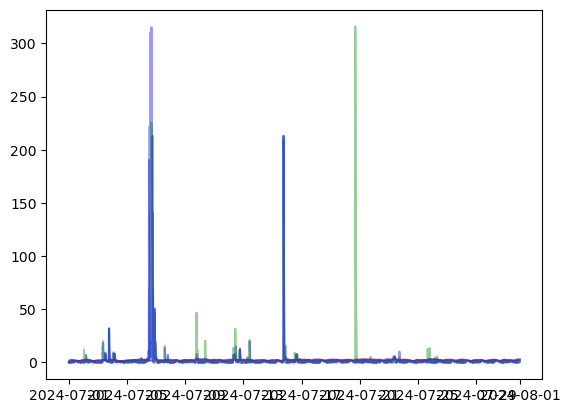

In [165]:
plt.plot(time,X_1,label='model',color='blue',alpha=0.4)
plt.plot(time,X,label='model',color='red',alpha=0.4)
plt.plot(time,X_2,label='model',color='green',alpha=0.4)
plt.plot(time,X_3,label='model',color='blue',alpha=0.4)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]

## Result analysis

In [166]:
my_prec = P*3600
count_prec = np.sum((rain_rate>0.38) & (my_prec > 0.25))
count_no_prec = np.sum((rain_rate==0) & (my_prec<0.25))
count_model_dubious = np.sum(
    (rain_rate> 0) & (rain_rate <= 0.38) & (my_prec  < 0.38)) #& (P * 3600 > 0.25)) \
  #+ np.sum((rain_rate == 0) & (P * 3600 < 0.38) )
count_wrong_prec = np.sum((rain_rate==0) & (my_prec> 0.25)) + np.sum((rain_rate > 0) & (rain_rate <= 0.38) & (my_prec > 0.38))
count_wrong_zero = np.sum((rain_rate>0.38) & (my_prec< 0.25))

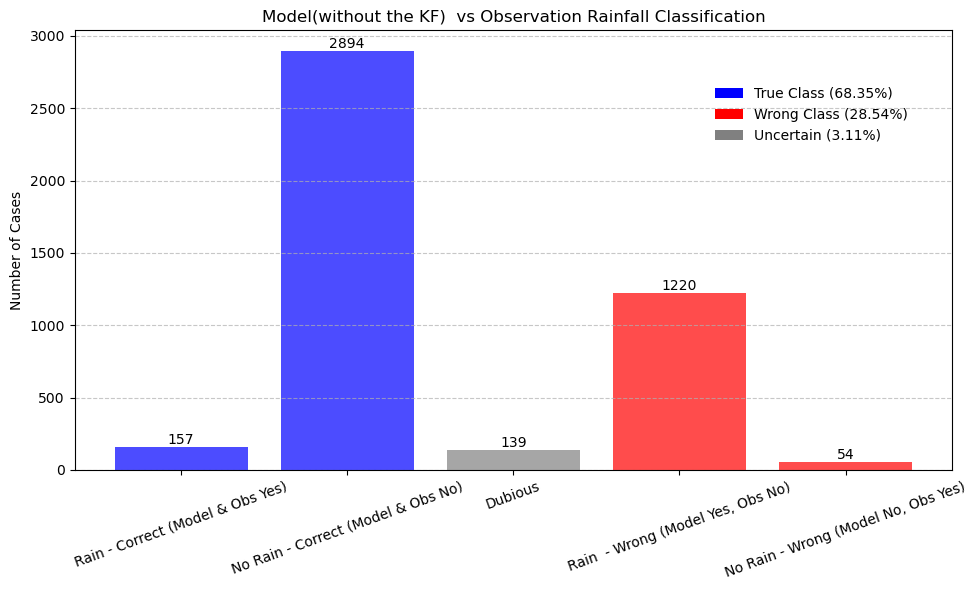

In [167]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define labels and values
labels = [
    'Rain - Correct (Model & Obs Yes)',
    'No Rain - Correct (Model & Obs No)',
    'Dubious',
    'Rain  - Wrong (Model Yes, Obs No)',
    'No Rain - Wrong (Model No, Obs Yes)'
]

values = [
    count_prec,
    count_no_prec,
    count_model_dubious,
    
    count_wrong_prec,
    count_wrong_zero
]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['blue', 'blue', 'gray','red', 'red'],alpha=0.7)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

legend_elements = [
    Patch(facecolor='blue', label=f'True Class ({(count_prec+count_no_prec)/4464*100:.2f}%)'),
    #Patch(facecolor='blue', label='Correct No Rain'),
    #Patch(facecolor='orange', label='Dubious Cases'),
    Patch(facecolor='red', label=f'Wrong Class ({(count_wrong_prec+count_wrong_zero)/4464*100:.2f}%)'),#label='Correct No Rain'),
    Patch(facecolor='grey', label=f'Uncertain ({(count_model_dubious)/4464*100:.2f}%)')
]

# Add the custom legend at the top
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.84, 0.9),
           ncol=1, frameon=False)
# Formatting
plt.title("Model(without the KF)  vs Observation Rainfall Classification")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


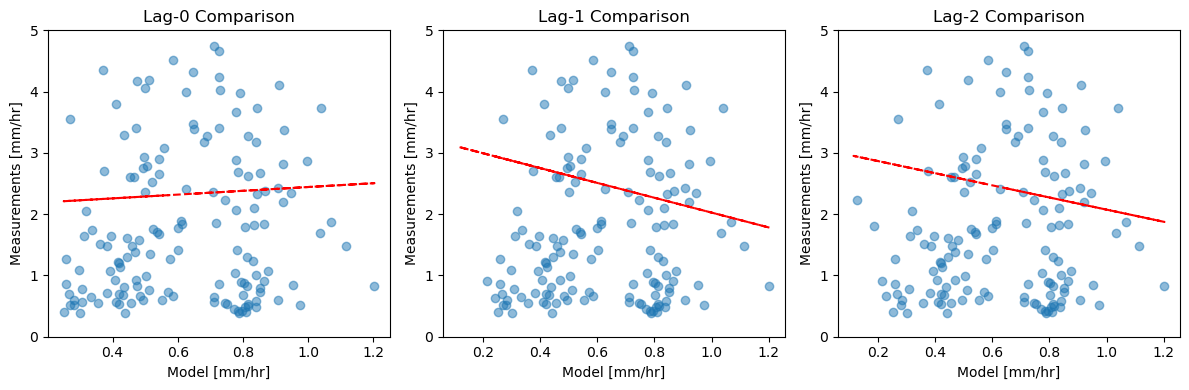

In [188]:
import matplotlib.pyplot as plt

# Prepare indices
indices     = np.where((rain_rate > 0.38) & (P * 3600 > 0.25))
indices_1   = np.where((rain_rate[0:-1] > 0.38) & (P[1:] * 3600 > 0.25))
indices_2   = np.where((rain_rate[0:-2] > 0.38) & (P[2:] * 3600 > 0.25))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(P[indices] * 3600, rain_rate[indices], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(P[indices] * 3600, rain_rate[indices], alpha=0.5)
axes[0].plot(P[indices] * 3600, p_0(P[indices] * 3600), "r--")
axes[0].set_title('Lag-0 Comparison')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')
axes[0].set_ylim(0, 5)

# Panel 2: Lag -1 (measurement leads model by 1)
z_1 = np.polyfit(P[indices_1] * 3600, rain_rate[indices_1], 1)
p_1 = np.poly1d(z_1)
axes[1].scatter(P[indices_1] * 3600, rain_rate[0:-1][indices_1], alpha=0.5)
axes[1].plot(P[indices_1] * 3600, p_1(P[indices_1] * 3600), "r--")
axes[1].set_title('Lag-1 Comparison')
axes[1].set_xlabel('Model [mm/hr]')
axes[1].set_ylabel('Measurements [mm/hr]')
axes[1].set_ylim(0, 5)
# Panel 3: Lag +1 (model leads measurement by 1)
z_2 = np.polyfit(P[indices_2] * 3600, rain_rate[indices_2], 1)
p_2 = np.poly1d(z_2)
axes[2].scatter(P[indices_2] * 3600, rain_rate[0:-2][indices_2], alpha=0.5)
axes[2].plot(P[indices_2] * 3600, p_2(P[indices_2] * 3600), "r--")
axes[2].set_title('Lag-2 Comparison')
axes[2].set_xlabel('Model [mm/hr]')
axes[2].set_ylabel('Measurements [mm/hr]')
axes[2].set_ylim(0, 5)
# Optional: consistent y-axis or limits
# for ax in axes:
#     ax.set_ylim(0, 10)
#     ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

In [189]:
print(pearsonr(rain_rate,P_1*3600),pearsonr(rain_rate,P_2*3600),pearsonr(rain_rate,P_3*3600))
print(pearsonr(rain_rate[indices_1],P[indices_1]*3600))

PearsonRResult(statistic=0.2474656991615604, pvalue=2.8324873188502186e-63) PearsonRResult(statistic=0.3365093476973536, pvalue=1.2775756991944762e-118) PearsonRResult(statistic=0.16310157631278016, pvalue=5.458488957633549e-28)
PearsonRResult(statistic=-0.08017963079596199, pvalue=0.3166077996340065)


Text(0.5, 0, 'Model [mm/hr]')

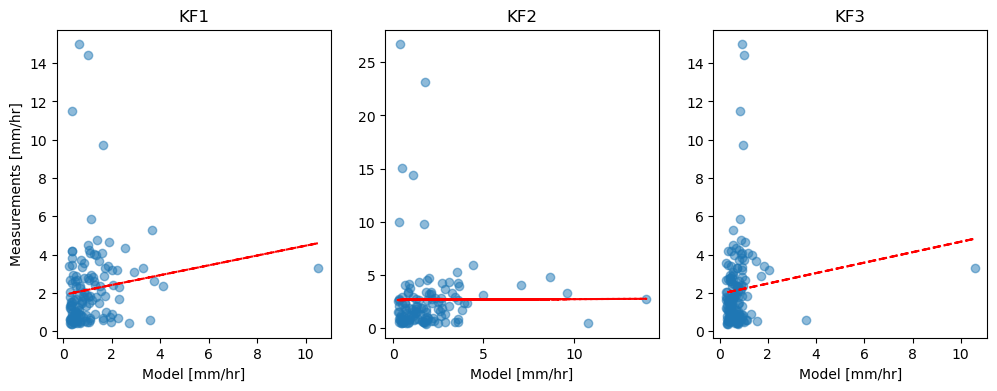

In [170]:
my_prec_1 = P_1*3600
my_prec_2 = P_2*3600
my_prec_3 = P_3*3600

indices_1     = np.where((rain_rate > 0.38) & (my_prec_1 > 0.25))
indices_2     = np.where((rain_rate > 0.38) & (my_prec_2 > 0.25))
indices_3     = np.where((rain_rate > 0.38) & (my_prec_3 > 0.25))
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(my_prec_1[indices_1], rain_rate[indices_1], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(my_prec_1[indices_1] , rain_rate[indices_1], alpha=0.5)
axes[0].plot(my_prec_1[indices_1], p_0(my_prec_1[indices_1] ), "r--")
axes[0].set_title('KF1')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_2[indices_2], rain_rate[indices_2], 1)
p_0 = np.poly1d(z_0)
axes[1].scatter(my_prec_2[indices_2] , rain_rate[indices_2], alpha=0.5)
axes[1].plot(my_prec_2[indices_2], p_0(my_prec_2[indices_2] ), "r--")
axes[1].set_title('KF2')
axes[1].set_xlabel('Model [mm/hr]')
#axes[0].set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_3[indices_3], rain_rate[indices_3], 1)
p_0 = np.poly1d(z_0)
axes[2].scatter(my_prec_3[indices_3] , rain_rate[indices_3], alpha=0.5)
axes[2].plot(my_prec_3[indices_3], p_0(my_prec_3[indices_3] ), "r--")
axes[2].set_title('KF3')
axes[2].set_xlabel('Model [mm/hr]')


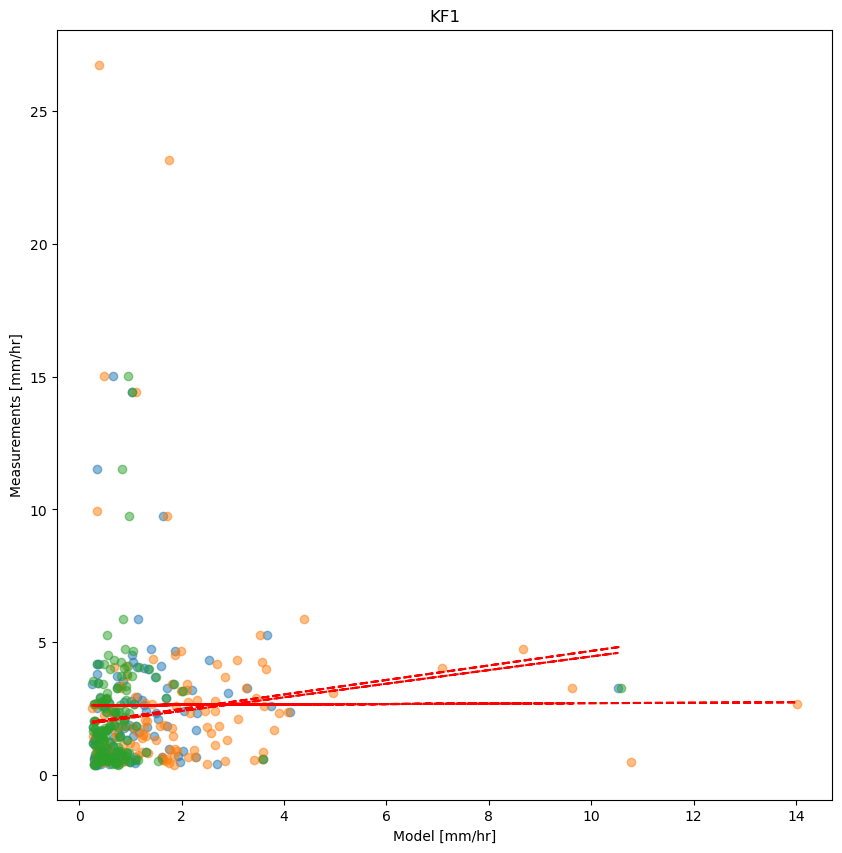

In [171]:
fig, axes = plt.subplots(1, 1, figsize=(10,10), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(my_prec_1[indices_1], rain_rate[indices_1], 1)
p_0 = np.poly1d(z_0)
axes.scatter(my_prec_1[indices_1] , rain_rate[indices_1], alpha=0.5)
axes.plot(my_prec_1[indices_1], p_0(my_prec_1[indices_1] ), "r--")
axes.set_title('KF1')
axes.set_xlabel('Model [mm/hr]')
axes.set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_2[indices_2], rain_rate[indices_2], 1)
p_0 = np.poly1d(z_0)
axes.scatter(my_prec_2[indices_2] , rain_rate[indices_2], alpha=0.5)
axes.plot(my_prec_2[indices_2], p_0(my_prec_2[indices_2] ), "r--")
#axes[0].set_title('KF2')
#axes[0].set_xlabel('Model [mm/hr]')
#axes[0].set_ylabel('Measurements [mm/hr]')

z_0 = np.polyfit(my_prec_3[indices_3], rain_rate[indices_3], 1)
p_0 = np.poly1d(z_0)
axes.scatter(my_prec_3[indices_3] , rain_rate[indices_3], alpha=0.5)
axes.plot(my_prec_3[indices_3], p_0(my_prec_3[indices_3] ), "r--")
#axes[0].set_title('KF3')
#axes[0].set_xlabel('Model [mm/hr]')

In [172]:
correlation = signal.correlate(rain_rate, P*3600, mode="full")

lags = signal.correlation_lags(rain_rate.size, P.size, mode="full")

lag = lags[np.argmax(correlation)]

In [173]:
print(pearsonr(rain_rate[indices_1],P_1[indices_1]*3600),pearsonr(rain_rate[indices_2],P_2[indices_2]*3600),pearsonr(rain_rate[indices_3],P_3[indices_3]*3600))
print(pearsonr(rain_rate,P*3600))

PearsonRResult(statistic=0.1283926044734034, pvalue=0.13485623825261278) PearsonRResult(statistic=0.004598134928680966, pvalue=0.959411174797511) PearsonRResult(statistic=0.11231714367499157, pvalue=0.17117907048129)
PearsonRResult(statistic=0.13128801606941207, pvalue=1.280156314892756e-18)


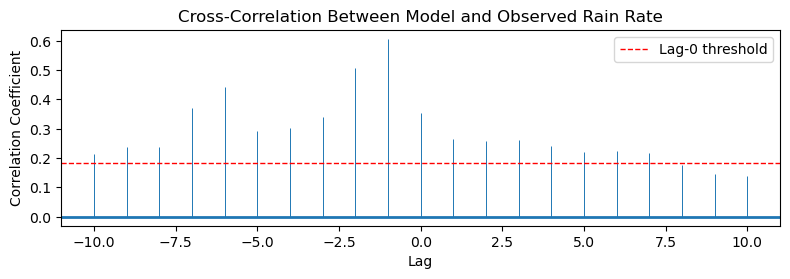

In [190]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(211)

# Cross-correlation
ax1.xcorr(rain_rate, P_2 * 3600, usevlines=True,
          maxlags=10, normed=True,
          lw=2, linewidth=0.7)

# Horizontal reference line
ax1.axhline(y=0.18337568, color='r', linestyle='dashed', linewidth=1, label='Lag-0 threshold')

# Axis labels and title
ax1.set_title('Cross-Correlation Between Model and Observed Rain Rate')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation Coefficient')

# Add legend
ax1.legend(loc='upper right')

# Optional: adjust layout
plt.tight_layout()
plt.show()


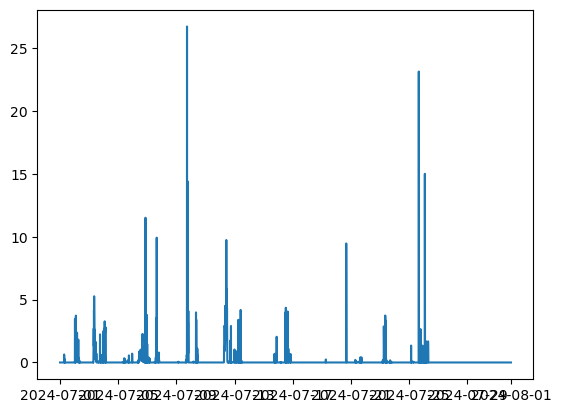

In [175]:
plt.plot(time,rain_rate,label='observation')

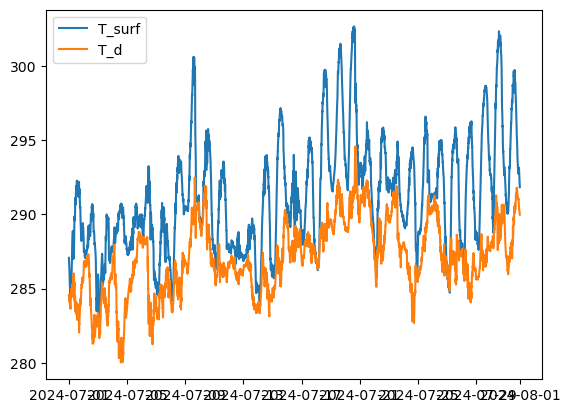

In [176]:
plt.plot(time,T_surf,label='T_surf')
plt.plot(time,T_d_arr,label='T_d')
plt.legend()

Text(0, 0.5, 'liquid water [kg/m^2]')

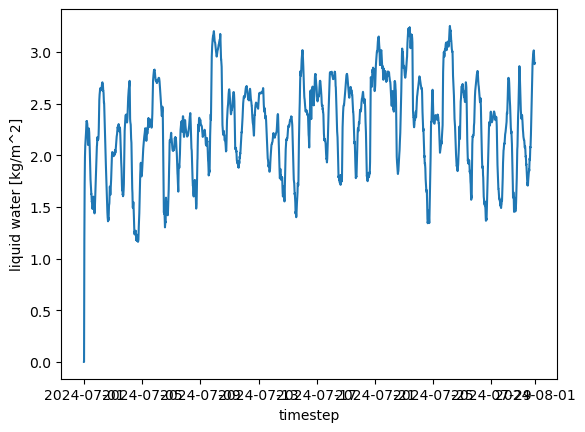

In [177]:
#state evolution

plt.plot(time,X)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
plt.ylabel('liquid water [kg/m^2]')

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

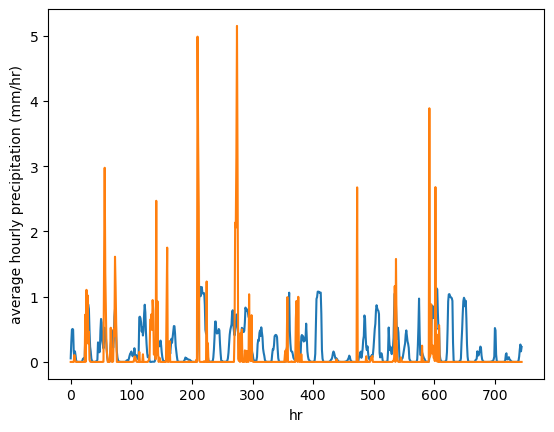

In [191]:
Pmeas = rain_rate
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

In [179]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)*5
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


2.861678495997993
2.8592679795489375
2.850955763799069
2.8557801536540404
2.858272230481497
2.856799343946523
2.8620726801773095
2.8628237671576504
2.8632645505356322
2.868506832716003
2.862414917763598
2.8643715629796858
2.8542271062454567
2.8587080445089583
2.8646032444141807
2.863100768499363
2.8649348069522125
2.8623637577984007
2.8669003691811596
2.879391186295834
2.881746501465455
2.8926424873080445
2.900806511249578
2.9019186702723085
2.9015168228761086
2.893482700136438
2.8879430166321924
2.892201492563092
2.8928219548620437
2.885132426389541
2.884947573766136
2.8900008840880274
2.8871039595394357
2.874588056360593
2.875553803920708
2.859893041536245
2.843920264695285
2.831480912221156
2.8428005873000686
2.8377312249308804
2.8544746268505246
2.890033052252707
2.899957783208608
2.893273838166988
2.8729558350203215
2.8823520108758114
2.8906499002718133
2.8966426228124753
2.886674668351837
2.8730779113001677
2.8727675204546252
2.8627670001225702
2.8538635253049933
2.85084319709035

Text(0, 0.5, 'updraft velocity [m/s]')

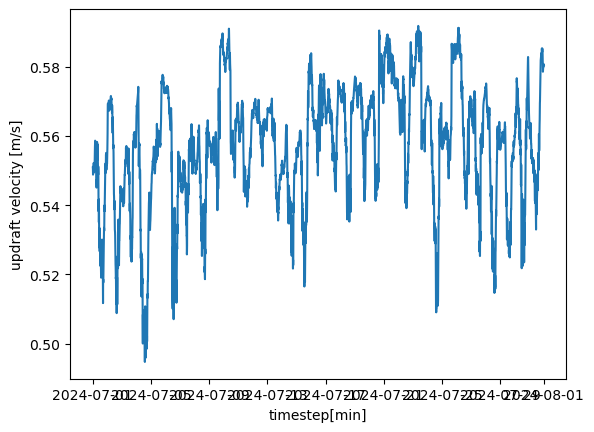

In [180]:
plt.plot(time,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')

Text(0.5, 1.0, 'Cloud Fluxes')

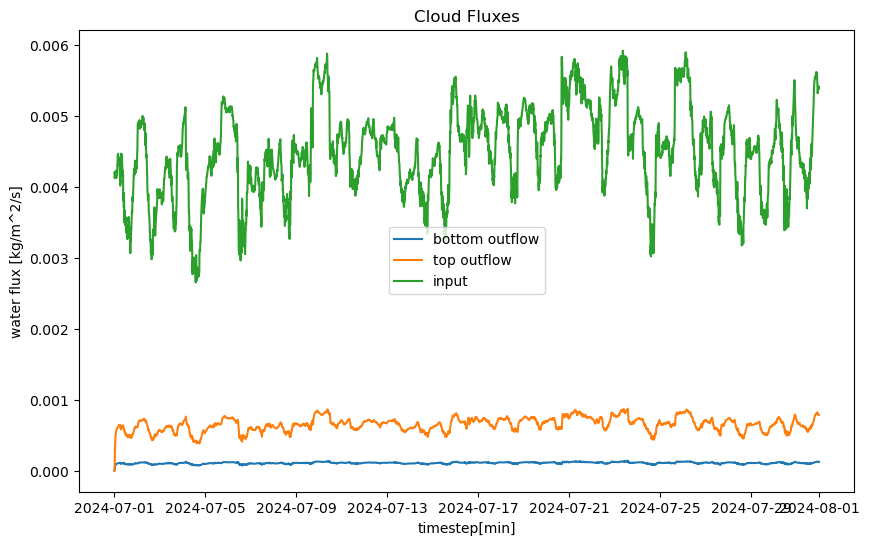

In [181]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(time,O_b_arr,label='bottom outflow')
plt.plot(time,O_h_arr,label='top outflow')
plt.plot(time,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')